# Lab 13 - Exploratory Data Analysis of the Training Corpus

**Goal:** understand what the current Wordle corpus actually teaches before generating or training on any new data.

Part II uses a different workflow:

> **Observe -> Analyze -> Hypothesize -> Experiment -> Measure -> Iterate**

This notebook is intentionally model-free. It loads the persisted Lab 06 v2 corpus, measures its distributions, checks split integrity, and ends with concrete hypotheses for Lab 14.

## 13.1 Questions we need to answer

We will inspect:

- examples and tokens by task;
- `NEXT_GUESS` frequency and target concentration;
- turn, candidate-count, difficulty, and history-depth distributions;
- answer coverage;
- repeated model-facing examples and repeated underlying states;
- train/dev distribution differences;
- interactions between `turn x candidate_count` and `task x difficulty`.

The output of this lab is a set of testable data hypotheses, not a new model.

In [1]:
from __future__ import annotations

from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from transformers import AutoTokenizer

pd.set_option("display.max_columns", 50)
pd.set_option("display.max_colwidth", 100)
plt.style.use("seaborn-v0_8-whitegrid")

DATA_DIR = Path("../data")
GENERATED_DIR = DATA_DIR / "generated"
MODEL_ID = "Qwen/Qwen3-0.6B"

FILES = {
    "train": GENERATED_DIR / "wordle-sft-train.jsonl",
    "dev": GENERATED_DIR / "wordle-sft-dev.jsonl",
    "test": GENERATED_DIR / "wordle-sft-test.jsonl",
}

for path in FILES.values():
    assert path.exists(), f"Run Lab 06 v2 first; missing {path}"

print("corpus files found")

corpus files found


## 13.2 Load the persisted corpus

We analyze the saved JSONL files rather than regenerating examples. This keeps the object of study identical to the data consumed by Labs 07-12.

In [2]:
frames = []

for file_split, path in FILES.items():
    split_df = pd.read_json(path, lines=True)
    assert split_df["split"].eq(file_split).all()
    frames.append(split_df)

df = pd.concat(frames, ignore_index=True)
manifest = json.loads(
    (GENERATED_DIR / "wordle-sft-manifest.json").read_text()
)

required_columns = {
    "task", "split", "answer", "turn", "candidate_count",
    "prompt", "response",
}
assert required_columns <= set(df.columns)
assert not df[list(required_columns)].isna().any().any()
assert len(df) == sum(manifest["counts"].values())

print("rows:", len(df))
print("columns:", list(df.columns))
display(df.head(3))

rows: 18824
columns: ['task', 'split', 'answer', 'turn', 'candidate_count', 'prompt', 'response']


,task,split,answer,turn,candidate_count,prompt,response
0,VALID_CANDIDATE,train,ABACK,2,92,"Task: VALID_CANDIDATE\nYou are playing Wordle.\nGiven the game history, decide whether the candi...",VALID
1,VALID_CANDIDATE,train,ABACK,2,92,"Task: VALID_CANDIDATE\nYou are playing Wordle.\nGiven the game history, decide whether the candi...",INVALID
2,CHOOSE_VALID,train,ABACK,2,92,Task: CHOOSE_VALID\nYou are playing Wordle.\nExactly one option is consistent with all previous ...,BLANK


## 13.3 Derive analysis features

`candidate_count` is converted into stable, ordered difficulty buckets. History depth is parsed from the exact model-facing prompt rather than inferred from `turn`, so representation bugs remain visible.

In [3]:
DIFFICULTY_LABELS = ["1-2", "3-10", "11-50", "51-200", "201+"]

def extract_history(prompt: str) -> str:
    marker = "History:\n"
    assert marker in prompt
    return prompt.split(marker, 1)[1].split("\n\n", 1)[0].strip()

def count_history_turns(prompt: str) -> int:
    history = extract_history(prompt)
    if history == "No previous guesses.":
        return 0
    return sum("->" in line for line in history.splitlines())

df["difficulty"] = pd.cut(
    df["candidate_count"],
    bins=[0, 2, 10, 50, 200, np.inf],
    labels=DIFFICULTY_LABELS,
    ordered=True,
)
df["history"] = df["prompt"].map(extract_history)
df["history_depth"] = df["prompt"].map(count_history_turns)
df["training_text"] = df["prompt"] + "\n" + df["response"]

history_mismatches = df.loc[df["history_depth"] != df["turn"] - 1]
assert history_mismatches.empty

display(df[[
    "task", "split", "turn", "history_depth",
    "candidate_count", "difficulty",
]].head())

,task,split,turn,history_depth,candidate_count,difficulty
0,VALID_CANDIDATE,train,2,1,92,51-200
1,VALID_CANDIDATE,train,2,1,92,51-200
2,CHOOSE_VALID,train,2,1,92,51-200
3,VALID_CANDIDATE,train,3,2,6,3-10
4,VALID_CANDIDATE,train,3,2,6,3-10


## 13.4 Corpus overview

Start with counts, but do not mistake example balance for training-signal balance. Longer prompts consume more tokens and therefore more optimization compute.

In [4]:
overview = pd.DataFrame({
    "examples": df.groupby("split").size(),
    "answers": df.groupby("split")["answer"].nunique(),
    "tasks": df.groupby("split")["task"].nunique(),
})
overview["example_share"] = overview["examples"] / len(df)
display(overview)

task_by_split = pd.crosstab(df["split"], df["task"])
display(task_by_split)
display(task_by_split.div(task_by_split.sum(axis=1), axis=0).round(3))

,examples,answers,tasks,example_share
split,,,,
dev,2169,231,3,0.115225
test,190,19,3,0.010093
train,16465,2064,3,0.874681


task,CHOOSE_VALID,NEXT_GUESS,VALID_CANDIDATE
split,,,
dev,602,385,1182
test,49,43,98
train,5353,1876,9236


task,CHOOSE_VALID,NEXT_GUESS,VALID_CANDIDATE
split,,,
dev,0.278,0.178,0.545
test,0.258,0.226,0.516
train,0.325,0.114,0.561


## 13.5 Examples versus training tokens

Token counts use the same tokenizer family as training. We include prompt and target text without padding; the comparison is about relative corpus composition, not packed-batch utilization.

,examples,tokens,mean_tokens,example_share,token_share
task,,,,,
VALID_CANDIDATE,10516,744476,70.795,0.559,0.551
CHOOSE_VALID,6004,452806,75.417,0.319,0.335
NEXT_GUESS,2304,152646,66.253,0.122,0.113


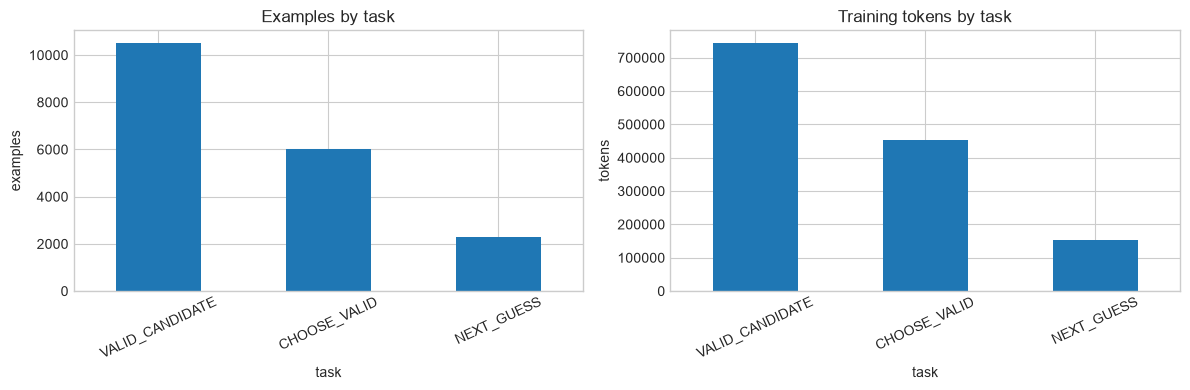

In [5]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
encoded = tokenizer(
    df["training_text"].tolist(),
    add_special_tokens=True,
    truncation=False,
    padding=False,
)
df["token_count"] = [len(ids) for ids in encoded["input_ids"]]

task_signal = (
    df.groupby("task", observed=True)
    .agg(
        examples=("task", "size"),
        tokens=("token_count", "sum"),
        mean_tokens=("token_count", "mean"),
    )
    .sort_values("examples", ascending=False)
)
task_signal["example_share"] = task_signal["examples"] / task_signal["examples"].sum()
task_signal["token_share"] = task_signal["tokens"] / task_signal["tokens"].sum()
display(task_signal.round(3))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
task_signal["examples"].plot.bar(ax=axes[0], title="Examples by task")
task_signal["tokens"].plot.bar(ax=axes[1], title="Training tokens by task")
axes[0].set_ylabel("examples")
axes[1].set_ylabel("tokens")
for ax in axes:
    ax.tick_params(axis="x", rotation=25)
plt.tight_layout()
plt.show()

## 13.6 How much policy data do we have?

`NEXT_GUESS` is the task closest to deployment gameplay. We measure its share by split and inspect whether a small number of teacher guesses dominate its targets.

In [6]:
next_guess = df.loc[df["task"] == "NEXT_GUESS"].copy()

next_guess_share = (
    df.assign(is_next_guess=df["task"].eq("NEXT_GUESS"))
    .groupby("split")["is_next_guess"]
    .agg(["sum", "count", "mean"])
    .rename(columns={"sum": "next_guess", "count": "all_examples", "mean": "share"})
)
display(next_guess_share.round(3))

target_counts = next_guess["response"].value_counts()
target_summary = pd.Series({
    "examples": len(next_guess),
    "unique_targets": next_guess["response"].nunique(),
    "singleton_target_share": target_counts.eq(1).mean(),
    "top_10_example_share": target_counts.head(10).sum() / len(next_guess),
    "most_frequent_target_count": target_counts.max(),
}, name="NEXT_GUESS targets")
display(target_summary.to_frame())
display(target_counts.head(20).rename("examples").to_frame())

,next_guess,all_examples,share
split,,,
dev,385,2169,0.178
test,43,190,0.226
train,1876,16465,0.114


,NEXT_GUESS targets
examples,2304.00000
unique_targets,2304.00000
singleton_target_share,1.00000
top_10_example_share,0.00434
most_frequent_target_count,1.00000


,examples
response,
CEASE,1
ABASE,1
ABATE,1
BEADY,1
ABBEY,1
ABBOT,1
ARBOR,1
ABHOR,1
ALIKE,1


## 13.7 Turns and history depth

Late-game states matter because mistakes on turns 5-6 directly become failed games. Compare the overall corpus with the policy subset.

task,CHOOSE_VALID,NEXT_GUESS,VALID_CANDIDATE
turn,,,
1,0,1,0
2,2314,131,3780
3,2183,999,3861
4,1184,919,2262
5,265,207,501
6,58,47,112


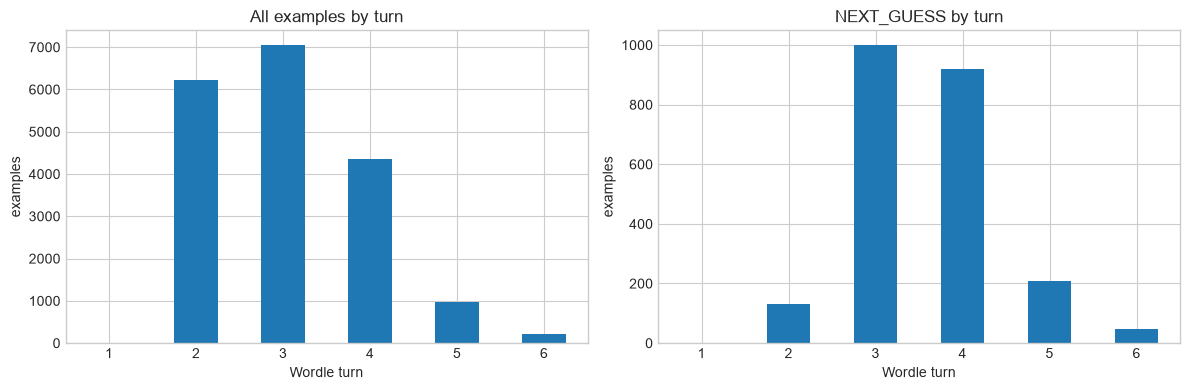

task,CHOOSE_VALID,NEXT_GUESS,VALID_CANDIDATE
history_depth,,,
0,0,1,0
1,2314,131,3780
2,2183,999,3861
3,1184,919,2262
4,265,207,501
5,58,47,112


In [7]:
turn_counts = pd.crosstab(df["turn"], df["task"]).sort_index()
display(turn_counts)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True)
df["turn"].value_counts().sort_index().plot.bar(ax=axes[0], title="All examples by turn")
next_guess["turn"].value_counts().sort_index().plot.bar(ax=axes[1], title="NEXT_GUESS by turn")
for ax in axes:
    ax.set_xlabel("Wordle turn")
    ax.set_ylabel("examples")
    ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

history_by_task = pd.crosstab(df["history_depth"], df["task"])
display(history_by_task)

## 13.8 Candidate counts and difficulty

Candidate count is highly skewed, so use both a log-scale histogram and interpretable buckets. Small candidate sets are not necessarily easy for a language model: they often require precise late-game exploitation.

,count,mean,std,min,25%,50%,75%,90%,99%,max
task,,,,,,,,,,
CHOOSE_VALID,6004.0,25.60,40.78,1.0,1.0,4.0,26.0,99.0,168.0,168.0
NEXT_GUESS,2304.0,3.61,48.79,1.0,1.0,1.0,2.0,4.0,26.0,2315.0
VALID_CANDIDATE,10516.0,23.66,39.56,1.0,1.0,4.0,25.0,92.0,168.0,168.0


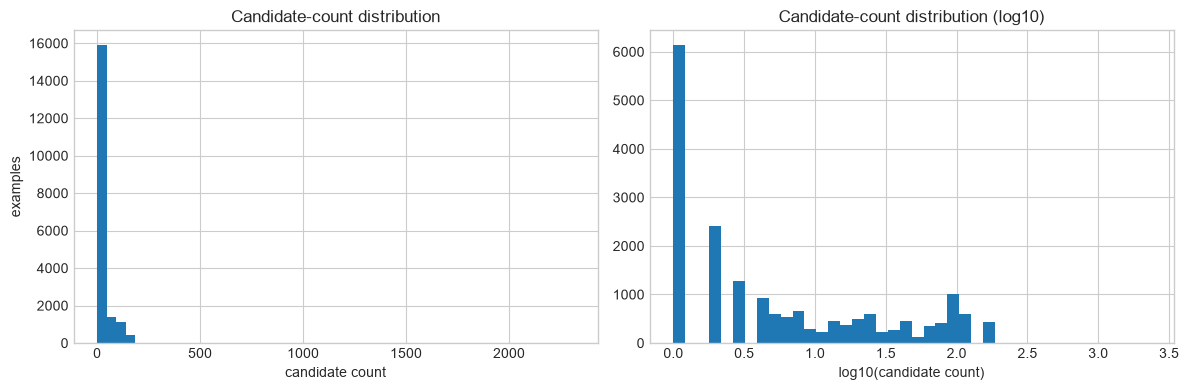

difficulty,1-2,3-10,11-50,51-200,201+
task,,,,,
CHOOSE_VALID,0.378,0.244,0.190,0.187,0.0
NEXT_GUESS,0.826,0.145,0.024,0.005,0.0
VALID_CANDIDATE,0.416,0.235,0.178,0.171,0.0


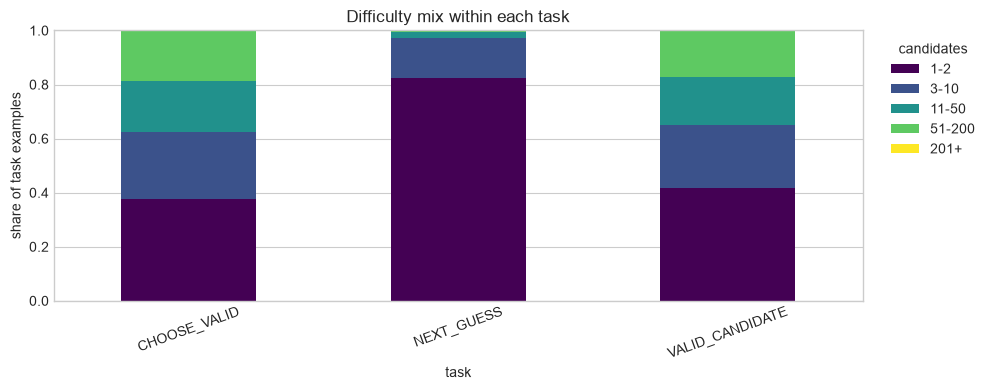

In [8]:
display(
    df.groupby("task")["candidate_count"]
    .describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.99])
    .round(2)
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df["candidate_count"], bins=50)
axes[0].set_title("Candidate-count distribution")
axes[0].set_xlabel("candidate count")
axes[0].set_ylabel("examples")

axes[1].hist(np.log10(df["candidate_count"]), bins=40)
axes[1].set_title("Candidate-count distribution (log10)")
axes[1].set_xlabel("log10(candidate count)")
plt.tight_layout()
plt.show()

difficulty_by_task = pd.crosstab(df["task"], df["difficulty"], normalize="index")
display(difficulty_by_task.round(3))
difficulty_by_task.plot.bar(stacked=True, figsize=(10, 4), colormap="viridis")
plt.title("Difficulty mix within each task")
plt.ylabel("share of task examples")
plt.xticks(rotation=20)
plt.legend(title="candidates", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

## 13.9 Cross important dimensions

Marginal distributions can hide holes. These tables reveal whether particular combinations of turn and difficulty receive little or no training signal.

difficulty,1-2,3-10,11-50,51-200,201+
turn,,,,,
1,0,0,0,0,1
2,184,661,2445,2935,0
3,3491,2928,624,0,0
4,3792,573,0,0,0
5,883,90,0,0,0
6,199,18,0,0,0


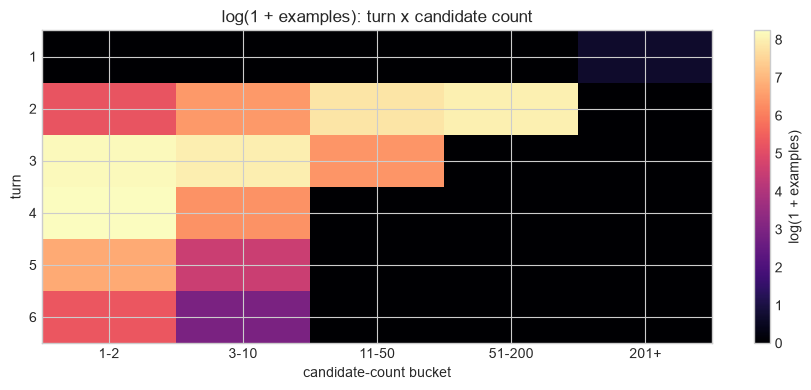

difficulty,1-2,3-10,11-50,51-200,201+
task,,,,,
CHOOSE_VALID,2271,1467,1143,1123,0
NEXT_GUESS,1902,334,55,12,1
VALID_CANDIDATE,4376,2469,1871,1800,0


In [9]:
turn_difficulty = pd.crosstab(df["turn"], df["difficulty"])
display(turn_difficulty)

fig, ax = plt.subplots(figsize=(9, 4))
image = ax.imshow(np.log1p(turn_difficulty.values), aspect="auto", cmap="magma")
ax.set_xticks(range(len(turn_difficulty.columns)), turn_difficulty.columns)
ax.set_yticks(range(len(turn_difficulty.index)), turn_difficulty.index)
ax.set_xlabel("candidate-count bucket")
ax.set_ylabel("turn")
ax.set_title("log(1 + examples): turn x candidate count")
fig.colorbar(image, ax=ax, label="log(1 + examples)")
plt.tight_layout()
plt.show()

task_difficulty = pd.crosstab(df["task"], df["difficulty"])
display(task_difficulty)

## 13.10 Answer coverage

The split is answer-level, so raw train/dev answer overlap must be zero. We also check which lexicon answers produce no examples and how many `NEXT_GUESS` decisions each answer contributes.

In [10]:
answers = {
    line.strip().upper()
    for line in (DATA_DIR / "wordle-answers-original.txt").read_text().splitlines()
    if line.strip()
}
answers_by_split = {
    split: set(group["answer"])
    for split, group in df.groupby("split")
}

assert answers_by_split["train"].isdisjoint(answers_by_split["dev"])
assert answers_by_split["train"].isdisjoint(answers_by_split["test"])
assert answers_by_split["dev"].isdisjoint(answers_by_split["test"])

covered_answers = set(df["answer"])
coverage = pd.Series({
    "lexicon_answers": len(answers),
    "covered_answers": len(covered_answers),
    "missing_answers": len(answers - covered_answers),
    "coverage_rate": len(covered_answers) / len(answers),
})
display(coverage.to_frame("value"))
print("missing answers:", sorted(answers - covered_answers))

policy_examples_per_answer = next_guess.groupby("answer").size()
display(policy_examples_per_answer.describe().to_frame("NEXT_GUESS examples per answer"))

,value
lexicon_answers,2315.000000
covered_answers,2314.000000
missing_answers,1.000000
coverage_rate,0.999568


missing answers: ['RAISE']


,NEXT_GUESS examples per answer
count,2051.000000
mean,1.123354
std,0.420099
min,1.000000
25%,1.000000
50%,1.000000
75%,1.000000
max,5.000000


## 13.11 Repeated examples and repeated states

There are three different duplication questions:

1. exact `(prompt, response)` duplicates repeat identical supervision;
2. prompts with multiple targets indicate ambiguity;
3. the same Wordle history reused across auxiliary tasks can cause a few states to dominate the corpus even when exact prompts are unique.

State reuse is not automatically bad, but it should be an intentional curriculum choice.

In [11]:
exact_duplicate_rows = df.duplicated(["prompt", "response"], keep=False)
prompt_target_counts = df.groupby("prompt")["response"].nunique()
state_reuse = df.groupby(["split", "history"]).agg(
    examples=("task", "size"),
    tasks=("task", "nunique"),
    answers=("answer", "nunique"),
).sort_values("examples", ascending=False)

duplication_summary = pd.Series({
    "rows_in_exact_duplicate_groups": int(exact_duplicate_rows.sum()),
    "ambiguous_prompts": int(prompt_target_counts.gt(1).sum()),
    "unique_histories": df["history"].nunique(),
    "histories_reused_within_split": int(state_reuse["examples"].gt(1).sum()),
    "max_examples_from_one_history": int(state_reuse["examples"].max()),
})
display(duplication_summary.to_frame("value"))
display(state_reuse.head(15))

,value
rows_in_exact_duplicate_groups,0
ambiguous_prompts,0
unique_histories,2304
histories_reused_within_split,2587
max_examples_from_one_history,362


examples  tasks  answers
split history                                         
train R A I S E -> B B B B B       362      2      142
      R A I S E -> B B B B Y       272      2      107
      R A I S E -> B B Y B B       254      2       99
      R A I S E -> Y B B B Y       240      2       93
      R A I S E -> Y B B B B       228      2       90
      R A I S E -> B Y B B B       221      2       85
      R A I S E -> B G B B B       221      2       87
      R A I S E -> B B B Y B       196      2       75
      R A I S E -> Y Y B B B       179      2       70
      R A I S E -> B Y B B Y       154      2       60
      R A I S E -> B B B B G       133      2       52
      R A I S E -> B Y B Y B       109      2       40
      R A I S E -> B B G B B       101      2       40
      R A I S E -> B B B Y Y        96      2       37
      R A I S E -> Y B B B G        94      2       36

## 13.12 Train versus dev distributions

A held-out split should differ in answers, not accidentally in task or difficulty mix. Total variation distance summarizes categorical drift: `0` means identical proportions and `1` means no overlap.

In [12]:
def normalized_distribution(data: pd.DataFrame, column: str) -> pd.Series:
    return data[column].value_counts(normalize=True, sort=False)

def compare_splits(column: str) -> tuple[pd.DataFrame, float]:
    comparison = pd.concat(
        {
            split: normalized_distribution(
                df.loc[df["split"] == split], column
            )
            for split in ["train", "dev"]
        },
        axis=1,
    ).fillna(0)
    comparison["absolute_gap"] = (comparison["train"] - comparison["dev"]).abs()
    total_variation = 0.5 * comparison["absolute_gap"].sum()
    return comparison, float(total_variation)

drift_rows = []
for column in ["task", "turn", "difficulty", "history_depth"]:
    comparison, total_variation = compare_splits(column)
    drift_rows.append({"dimension": column, "total_variation": total_variation})
    print(f"\n{column} (TV={total_variation:.4f})")
    display(comparison.round(4))

drift_df = pd.DataFrame(drift_rows).sort_values("total_variation", ascending=False)
display(drift_df)


task (TV=0.0636)


,train,dev,absolute_gap
task,,,
VALID_CANDIDATE,0.5609,0.5450,0.0160
CHOOSE_VALID,0.3251,0.2775,0.0476
NEXT_GUESS,0.1139,0.1775,0.0636



turn (TV=0.0206)


,train,dev,absolute_gap
turn,,,
2,0.3295,0.3347,0.0052
3,0.3727,0.3850,0.0122
4,0.2345,0.2144,0.0201
5,0.0521,0.0516,0.0005
6,0.0111,0.0143,0.0032



difficulty (TV=0.0197)


,train,dev,absolute_gap
difficulty,,,
1-2,0.4577,0.4380,0.0197
3-10,0.2242,0.2370,0.0127
11-50,0.1625,0.1664,0.0039
51-200,0.1555,0.1586,0.0031
201+,0.0000,0.0000,0.0000



history_depth (TV=0.0206)


,train,dev,absolute_gap
history_depth,,,
1,0.3295,0.3347,0.0052
2,0.3727,0.3850,0.0122
3,0.2345,0.2144,0.0201
4,0.0521,0.0516,0.0005
5,0.0111,0.0143,0.0032


,dimension,total_variation
0,task,0.063562
1,turn,0.020587
3,history_depth,0.020587
2,difficulty,0.019708


## 13.13 Compact diagnostic scorecard

This scorecard turns the plots into values that can guide Lab 14. It deliberately reports observations without prescribing arbitrary target percentages.

In [13]:
train = df.loc[df["split"] == "train"]
train_policy = train.loc[train["task"] == "NEXT_GUESS"]
train_target_counts = train_policy["response"].value_counts()

scorecard = pd.Series({
    "train examples": len(train),
    "train tokens": int(train["token_count"].sum()),
    "NEXT_GUESS example share": train["task"].eq("NEXT_GUESS").mean(),
    "NEXT_GUESS token share": (
        train.loc[train["task"] == "NEXT_GUESS", "token_count"].sum()
        / train["token_count"].sum()
    ),
    "late-game (turn 5-6) example share": train["turn"].ge(5).mean(),
    "late-game NEXT_GUESS share": train_policy["turn"].ge(5).mean(),
    "multi-turn (history >= 3) share": train["history_depth"].ge(3).mean(),
    "small-set (<= 10) share": train["candidate_count"].le(10).mean(),
    "unique NEXT_GUESS target rate": (
        train_policy["response"].nunique() / len(train_policy)
    ),
    "top-10 NEXT_GUESS target share": (
        train_target_counts.head(10).sum() / len(train_policy)
    ),
    "answer coverage": len(covered_answers) / len(answers),
})
display(scorecard.to_frame("value").style.format("{:.3f}"))

,value
train examples,16465.000
train tokens,1183628.000
NEXT_GUESS example share,0.114
NEXT_GUESS token share,0.106
late-game (turn 5-6) example share,0.063
late-game NEXT_GUESS share,0.116
multi-turn (history >= 3) share,0.298
small-set (<= 10) share,0.682
unique NEXT_GUESS target rate,1.000
top-10 NEXT_GUESS target share,0.005


## 13.14 Write evidence-based hypotheses

Complete these statements using the scorecard and plots above. Each hypothesis must name an observation, an expected behavioral consequence, and a measurable intervention.

### Hypothesis 1 - Policy-task allocation

**Observation:** `NEXT_GUESS` accounts for ___ of train examples and ___ of train tokens.

**Expected consequence:** ___

**Lab 14 intervention:** ___

### Hypothesis 2 - Late-game and long-history coverage

**Observation:** Turns 5-6 account for ___ of policy examples; histories of depth 3+ account for ___ of all examples.

**Expected consequence:** ___

**Lab 14 intervention:** ___

### Hypothesis 3 - Candidate-count balance

**Observation:** ___

**Expected consequence:** ___

**Lab 14 intervention:** ___

### Hypothesis 4 - State reuse and diversity

**Observation:** ___

**Expected consequence:** ___

**Lab 14 intervention:** ___

### Hypothesis 5 - Split comparability

**Observation:** the largest train/dev total variation distance is ___ on dimension ___.

**Expected consequence:** ___

**Lab 14 intervention:** ___

# Lab 13 checkpoint

Before moving to Lab 14, record:

1. the task and token distribution table;
2. `NEXT_GUESS` example/token shares;
3. late-game and long-history shares;
4. the weakest `turn x candidate_count` regions;
5. answer coverage and state-reuse results;
6. train/dev total variation distances;
7. at least three hypotheses in the observation -> consequence -> intervention format.

Lab 14 will use those observations to define Dataset B while preserving Dataset A as the control.